In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
BATCH_SIZE = 64
IMAGE_SIZE = 128
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "./train",
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE 
)
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "./test",
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE  
)

Found 6740 files belonging to 10 classes.
Found 1791 files belonging to 10 classes.


2022-05-15 18:53:30.383658: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
class_names = train_dataset.class_names
class_names

['Acne and Rosacea Photos',
 'Eczema Photos',
 'Exanthems and Drug Eruptions',
 'Hair Loss Photos Alopecia and other Hair Diseases',
 'Lupus and other Connective Tissue diseases',
 'Melanoma Skin Cancer Nevi and Moles',
 'Nail Fungus and other Nail Disease',
 'Psoriasis pictures Lichen Planus and related diseases',
 'Urticaria Hives',
 'Vascular Tumors']

In [4]:
len(train_dataset)

106

In [5]:
def get_dataset_partitions_tf(ds, train_split = 0.8,val_split = 0.2,shuffle = True,shuffle_size = 5000):
  assert(train_split+val_split) == 1
  ds_size = len(ds)
  if shuffle:
    ds = ds.shuffle(shuffle_size, seed = 12)
  train_size = int(train_split*ds_size)
  val_size = int(val_split * ds_size)

  train_ds = ds.take(train_size)
  val_ds = ds.skip(train_size).take(val_size)
  return train_ds, val_ds

In [6]:
train_ds, val_ds = get_dataset_partitions_tf(train_dataset)

In [7]:
train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_ds = val_ds.cache().shuffle(500).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_dataset.cache().shuffle(500).prefetch(buffer_size=tf.data.AUTOTUNE)

In [8]:
resize_and_rescale = tf.keras.Sequential([
                     layers.experimental.preprocessing.Resizing(IMAGE_SIZE,IMAGE_SIZE),
                     layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [9]:
data_augmentation = tf.keras.Sequential([
                     layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
                     layers.experimental.preprocessing.RandomRotation(0.2),
])

In [10]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [11]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

base_model.trainable = False
model = tf.keras.Sequential([
    resize_and_rescale,
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'), 
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128,activation = 'relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10,activation='softmax') #23 here!!!!!or 17 or 10
])

model.build(input_shape = (BATCH_SIZE,128,128,3))

In [12]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (64, 128, 128, 3)         0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 1280)             2257984   
 ional)                                                          
                                                                 
 flatten (Flatten)           (64, 1280)                0         
                                                                 
 dense (Dense)               (64, 1024)                1311744   
                                                                 
 dropout (Dropout)           (64, 1024)                0         
                                                                 
 dense_1 (Dense)             (64, 512)                 524800    
                                                      

In [13]:
from tensorflow.keras.optimizers import RMSprop, SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint('skin_disease.h5',
                             monitor='val_loss',
                             mode='min',
                             save_best_only=True,
                             verbose=1)

earlystop = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=5,
                          verbose=1,
                          restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=5,
                              verbose=1,
                              min_delta=0.0001)

callbacks = [earlystop,checkpoint,reduce_lr]

In [14]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [15]:
EPOCHS = 100
history = model.fit(
    train_ds,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    validation_data = val_ds,
    callbacks = callbacks,
    verbose = 1,
)

Epoch 1/100


2022-05-15 18:53:44.380676: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 97 of 5000
2022-05-15 18:53:44.440377: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:415] Shuffle buffer filled.
2022-05-15 18:53:44.440426: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 1 of 500
2022-05-15 18:53:44.471718: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:415] Shuffle buffer filled.


84/84 [==============================] - ETA: 0s - loss: 2.1014 - accuracy: 0.2663
Epoch 1: val_loss improved from inf to 1.79658, saving model to skin_disease.h5
84/84 [==============================] - 66s 644ms/step - loss: 2.1014 - accuracy: 0.2663 - val_loss: 1.7966 - val_accuracy: 0.3914 - lr: 1.0000e-04
Epoch 2/100
84/84 [==============================] - ETA: 0s - loss: 1.8616 - accuracy: 0.3571
Epoch 2: val_loss improved from 1.79658 to 1.71157, saving model to skin_disease.h5
84/84 [==============================] - 57s 681ms/step - loss: 1.8616 - accuracy: 0.3571 - val_loss: 1.7116 - val_accuracy: 0.3973 - lr: 1.0000e-04
Epoch 3/100
84/84 [==============================] - ETA: 0s - loss: 1.7664 - accuracy: 0.3953
Epoch 3: val_loss improved from 1.71157 to 1.65412, saving model to skin_disease.h5
84/84 [==============================] - 58s 692ms/step - loss: 1.7664 - accuracy: 0.3953 - val_loss: 1.6541 - val_accuracy: 0.4256 - lr: 1.0000e-04
Epoch 4/100
84/84 [=============

2022-05-15 19:05:51.645684: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 95 of 5000
2022-05-15 19:05:51.945315: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:415] Shuffle buffer filled.



Epoch 12: val_loss improved from 1.44450 to 1.38988, saving model to skin_disease.h5
84/84 [==============================] - 69s 824ms/step - loss: 1.5082 - accuracy: 0.4736 - val_loss: 1.3899 - val_accuracy: 0.5275 - lr: 1.0000e-04
Epoch 13/100
84/84 [==============================] - ETA: 0s - loss: 1.4854 - accuracy: 0.4760
Epoch 13: val_loss did not improve from 1.38988
84/84 [==============================] - 72s 855ms/step - loss: 1.4854 - accuracy: 0.4760 - val_loss: 1.4290 - val_accuracy: 0.5097 - lr: 1.0000e-04
Epoch 14/100
84/84 [==============================] - ETA: 0s - loss: 1.4636 - accuracy: 0.4863
Epoch 14: val_loss improved from 1.38988 to 1.36847, saving model to skin_disease.h5
84/84 [==============================] - 62s 743ms/step - loss: 1.4636 - accuracy: 0.4863 - val_loss: 1.3685 - val_accuracy: 0.5268 - lr: 1.0000e-04
Epoch 15/100
84/84 [==============================] - ETA: 0s - loss: 1.4477 - accuracy: 0.4919
Epoch 15: val_loss did not improve from 1.3684

...


Epoch 30: val_loss improved from 1.22364 to 1.21223, saving model to skin_disease.h5
84/84 [==============================] - 69s 819ms/step - loss: 1.2740 - accuracy: 0.5512 - val_loss: 1.2122 - val_accuracy: 0.5863 - lr: 1.0000e-04
Epoch 31/100
84/84 [==============================] - ETA: 0s - loss: 1.2473 - accuracy: 0.5611
Epoch 31: val_loss improved from 1.21223 to 1.17743, saving model to skin_disease.h5
84/84 [==============================] - 62s 736ms/step - loss: 1.2473 - accuracy: 0.5611 - val_loss: 1.1774 - val_accuracy: 0.5841 - lr: 1.0000e-04
Epoch 32/100
84/84 [==============================] - ETA: 0s - loss: 1.2304 - accuracy: 0.5741
Epoch 32: val_loss did not improve from 1.17743
84/84 [==============================] - 56s 668ms/step - loss: 1.2304 - accuracy: 0.5741 - val_loss: 1.2434 - val_accuracy: 0.5573 - lr: 1.0000e-04
Epoch 33/100
84/84 [==============================] - ETA: 0s - loss: 1.2293 - accuracy: 0.5617
Epoch 33: val_loss did not improve from 1.1774

2022-05-15 19:31:32.223150: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 94 of 5000
2022-05-15 19:31:32.619331: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:415] Shuffle buffer filled.



Epoch 37: val_loss improved from 1.14447 to 1.13985, saving model to skin_disease.h5
84/84 [==============================] - 70s 838ms/step - loss: 1.1708 - accuracy: 0.5896 - val_loss: 1.1399 - val_accuracy: 0.5915 - lr: 1.0000e-04
Epoch 38/100
84/84 [==============================] - ETA: 0s - loss: 1.1698 - accuracy: 0.5928
Epoch 38: val_loss did not improve from 1.13985
84/84 [==============================] - 68s 809ms/step - loss: 1.1698 - accuracy: 0.5928 - val_loss: 1.1673 - val_accuracy: 0.5975 - lr: 1.0000e-04
Epoch 39/100
84/84 [==============================] - ETA: 0s - loss: 1.1684 - accuracy: 0.5851
Epoch 39: val_loss improved from 1.13985 to 1.11647, saving model to skin_disease.h5
84/84 [==============================] - 62s 735ms/step - loss: 1.1684 - accuracy: 0.5851 - val_loss: 1.1165 - val_accuracy: 0.6054 - lr: 1.0000e-04
Epoch 40/100
84/84 [==============================] - ETA: 0s - loss: 1.1374 - accuracy: 0.6002
Epoch 40: val_loss did not improve from 1.1164

2022-05-15 19:38:22.390219: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 106 of 5000
2022-05-15 19:38:22.390247: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:415] Shuffle buffer filled.



Epoch 44: val_loss improved from 1.09619 to 1.07715, saving model to skin_disease.h5
84/84 [==============================] - 65s 773ms/step - loss: 1.1047 - accuracy: 0.6073 - val_loss: 1.0771 - val_accuracy: 0.6302 - lr: 1.0000e-04
Epoch 45/100
84/84 [==============================] - ETA: 0s - loss: 1.0854 - accuracy: 0.6182
Epoch 45: val_loss did not improve from 1.07715
84/84 [==============================] - 54s 646ms/step - loss: 1.0854 - accuracy: 0.6182 - val_loss: 1.0877 - val_accuracy: 0.6168 - lr: 1.0000e-04
Epoch 46/100
84/84 [==============================] - ETA: 0s - loss: 1.0813 - accuracy: 0.6157
Epoch 46: val_loss did not improve from 1.07715
84/84 [==============================] - 52s 621ms/step - loss: 1.0813 - accuracy: 0.6157 - val_loss: 1.0817 - val_accuracy: 0.6243 - lr: 1.0000e-04
Epoch 47/100
84/84 [==============================] - ETA: 0s - loss: 1.0889 - accuracy: 0.6227
Epoch 47: val_loss improved from 1.07715 to 1.05543, saving model to skin_disease.h

In [16]:
scores = model.evaluate(test_ds)

28/28 [==============================] - 61s 2s/step - loss: 1.3285 - accuracy: 0.5327


In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

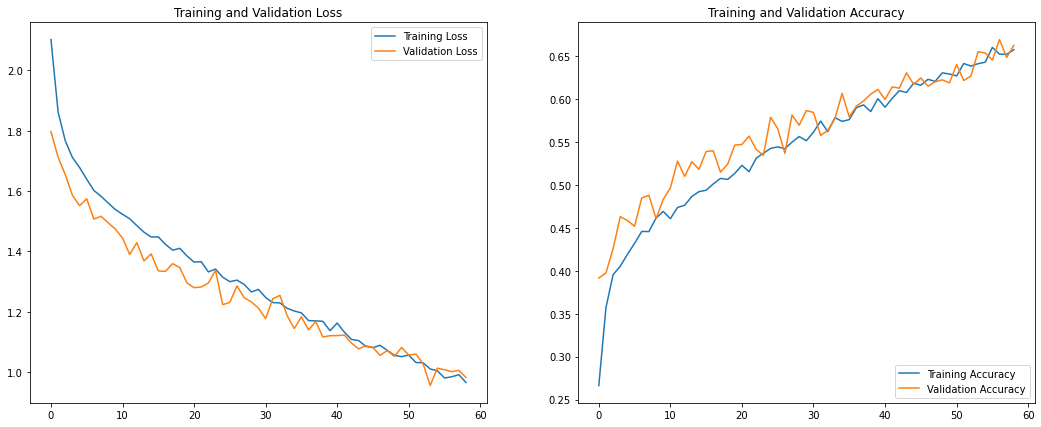

In [27]:
plt.figure(figsize=(18,7))
plt.subplot(1, 2, 1)
plt.plot(range(59), loss, label='Training Loss') #range(EPOCHS) => range(59) same for the following 3
plt.plot(range(59), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(range(59), acc, label='Training Accuracy')
plt.plot(range(59), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

first image to predict
actual label: Acne and Rosacea Photos
predicted label: Psoriasis pictures Lichen Planus and related diseases


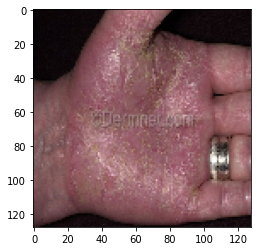

In [19]:
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[23].numpy().astype('uint8')
    first_label = labels_batch[25].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[23])])

In [20]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

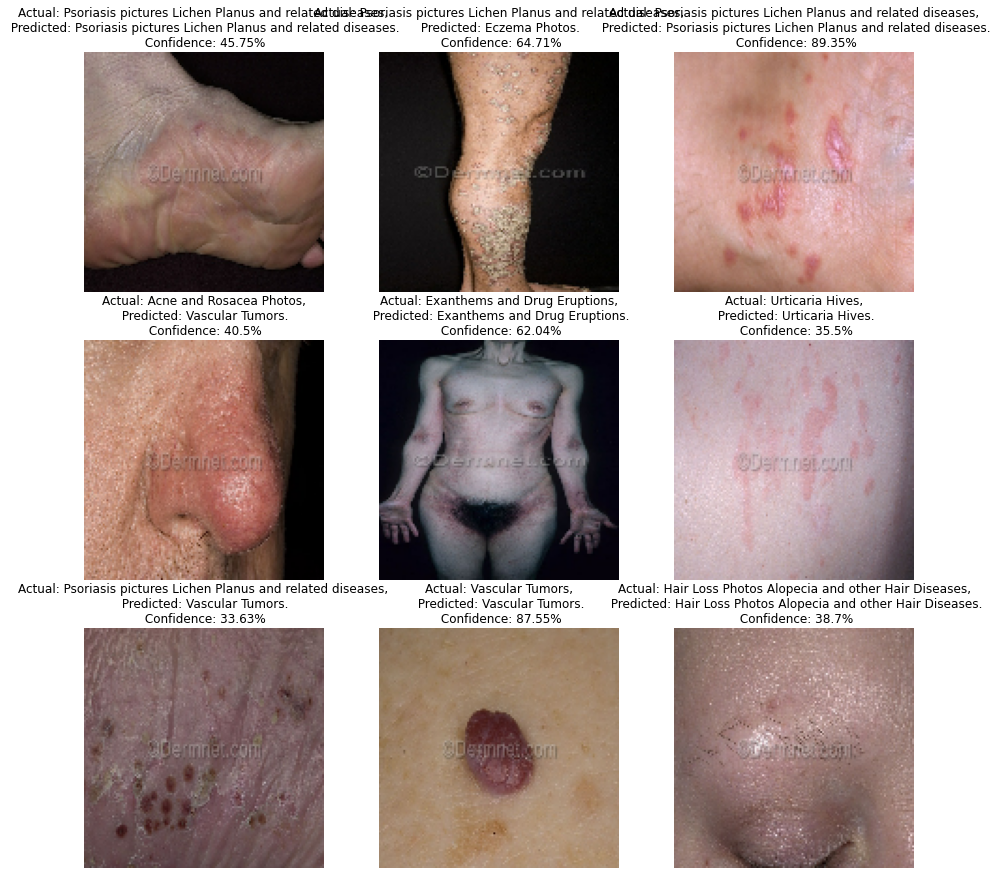

In [26]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [23]:
model.save("./model/build")

2022-05-15 19:56:13.650830: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: ./model/build/assets
